<a href="https://colab.research.google.com/github/Saphirarya/AI-Lab-4/blob/main/applied_ML_CW1_assignment_jonmiller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

load the dataset

In [55]:
# File already uploaded to session
df = pd.read_csv('IoT_Intrusion.csv')
print('✅ Dataset loaded from session files')

✅ Dataset loaded from session files


In [56]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1048575 non-null  float64
 1   Header_Length    1048575 non-null  float64
 2   Protocol Type    1048575 non-null  float64
 3   Duration         1048575 non-null  float64
 4   Rate             1048575 non-null  float64
 5   Srate            1048575 non-null  float64
 6   Drate            1048575 non-null  float64
 7   fin_flag_number  1048575 non-null  int64  
 8   syn_flag_number  1048575 non-null  int64  
 9   rst_flag_number  1048575 non-null  int64  
 10  psh_flag_number  1048575 non-null  int64  
 11  ack_flag_number  1048575 non-null  int64  
 12  ece_flag_number  1048575 non-null  int64  
 13  cwr_flag_number  1048575 non-null  int64  
 14  ack_count        1048575 non-null  float64
 15  syn_count        1048575 non-null  float64
 16  fin_count        1

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.763553e+00,7.759537e+04,9.062979e+00,6.635523e+01,9.146945e+03,9.146945e+03,1.807621e-06,8.655842e-02,2.073090e-01,9.057149e-02,...,1.248502e+02,3.345817e+01,1.248978e+02,8.317382e+07,9.497998e+00,1.312711e+01,4.728151e+01,3.147998e+04,9.635824e-02,1.414999e+02
std,2.965660e+02,4.664043e+05,8.936737e+00,1.408680e+01,9.974794e+04,9.974794e+04,8.501385e-04,2.811870e-01,4.053790e-01,2.869989e-01,...,2.420296e+02,1.622552e+02,2.429223e+02,1.703857e+07,8.187710e-01,8.639921e+00,2.294819e+02,3.645895e+05,2.327718e-01,2.105725e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.087155e+00,2.087155e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.581371e+01,1.581371e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.042881e-01,2.781200e+02,1.428000e+01,6.400000e+01,1.174380e+02,1.174380e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405208e+01,3.777740e-01,5.406000e+01,8.334390e+07,9.500000e+00,1.039675e+01,5.059213e-01,1.370916e+00,8.000000e-02,1.415500e+02
max,9.943576e+04,9.815555e+06,4.700000e+01,2.550000e+02,7.340032e+06,7.340032e+06,8.484654e-01,1.000000e+00,1.000000e+00,1.000000e+00,...,8.040961e+03,1.099626e+04,1.309800e+04,1.676394e+08,1.500000e+01,1.252094e+02,1.555106e+04,1.372844e+08,1.000000e+00,2.446000e+02


In [57]:
df = pd.read_csv('IoT_Intrusion.csv')

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nColumn names:')
print(df.columns.tolist())
print('\nLabel distribution:')
print(df['label'].value_counts())

Dataset shape: (1048575, 47)

First 5 rows:
   flow_duration  Header_Length  Protocol Type  Duration         Rate  \
0       0.000000          54.00           6.00     64.00     0.329807   
1       0.000000          57.04           6.33     64.00     4.290556   
2       0.000000           0.00           1.00     64.00    33.396799   
3       0.328175       76175.00          17.00     64.00  4642.133010   
4       0.117320         101.73           6.11     65.91     6.202211   

         Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  ...  \
0     0.329807    0.0                1                0                1  ...   
1     4.290556    0.0                0                0                0  ...   
2    33.396799    0.0                0                0                0  ...   
3  4642.133010    0.0                0                0                0  ...   
4     6.202211    0.0                0                1                0  ...   

         Std  Tot size        

In [58]:
# group  into 8 categories
category_map = {
    # DDoS family
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS',
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    # DoS family
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    # Mirai family
    'Mirai-greeth_flood': 'Mirai', 'Mirai-udpplain': 'Mirai', 'Mirai-greip_flood': 'Mirai',
    # Spoofing family
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    # Recon family
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    # Web-based family
    'SqlInjection': 'Web-based', 'CommandInjection': 'Web-based', 'Backdoor_Malware': 'Web-based',
    'XSS': 'Web-based', 'BrowserHijacking': 'Web-based', 'Uploading_Attack': 'Web-based',
    # Brute Force
    'DictionaryBruteForce': 'BruteForce',
    # Benign
    'BenignTraffic': 'Benign'
}

# Apply mapping
df['Category'] = df['label'].map(category_map)

print('Category distribution:')
print(df['Category'].value_counts())

Category distribution:
Category
DDoS          763525
DoS           181481
Mirai          59233
Benign         24476
Spoofing       11053
Recon           7945
Web-based        538
BruteForce       324
Name: count, dtype: int64


In [59]:
# Encode categories to numbers
le = LabelEncoder()

# Features (drop label and Category)
X = df.drop(['label', 'Category'], axis=1)

# Target (convert categories to numbers 0-7)
y = le.fit_transform(df['Category'])

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Number of classes: {len(le.classes_)}')
print(f'Class names: {le.classes_}')

Features shape: (1048575, 46)
Target shape: (1048575,)
Number of classes: 8
Class names: ['Benign' 'BruteForce' 'DDoS' 'DoS' 'Mirai' 'Recon' 'Spoofing' 'Web-based']


In [60]:
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(pd.Series(y_train).value_counts().sort_index())


Training set: 838860 samples
Test set: 209715 samples

Training class distribution:
0     19581
1       259
2    610820
3    145185
4     47386
5      6356
6      8843
7       430
Name: count, dtype: int64


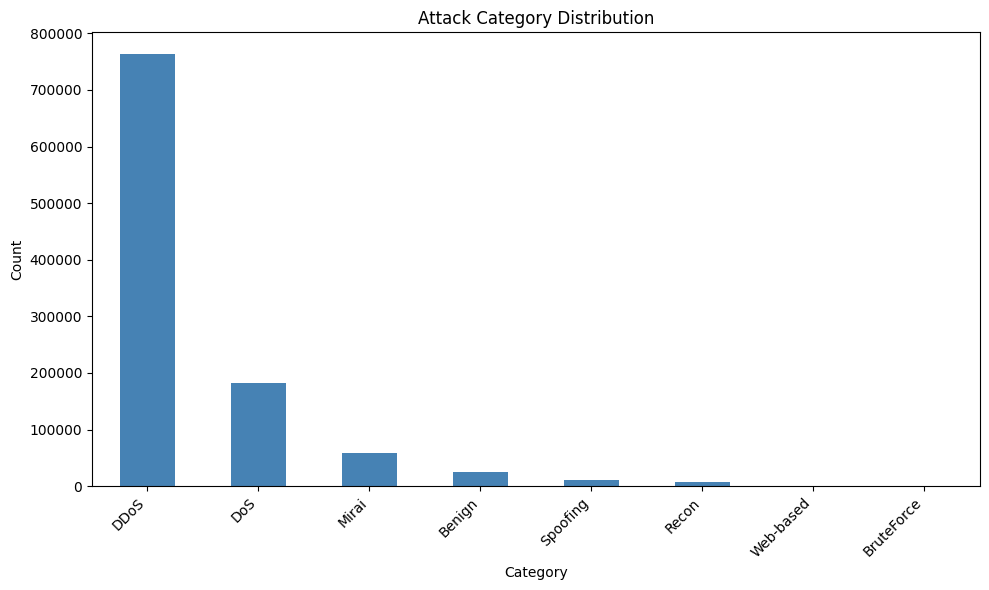

Category
DDoS          763525
DoS           181481
Mirai          59233
Benign         24476
Spoofing       11053
Recon           7945
Web-based        538
BruteForce       324
Name: count, dtype: int64


In [61]:
# Class distribution visualization
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Attack Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(df['Category'].value_counts())

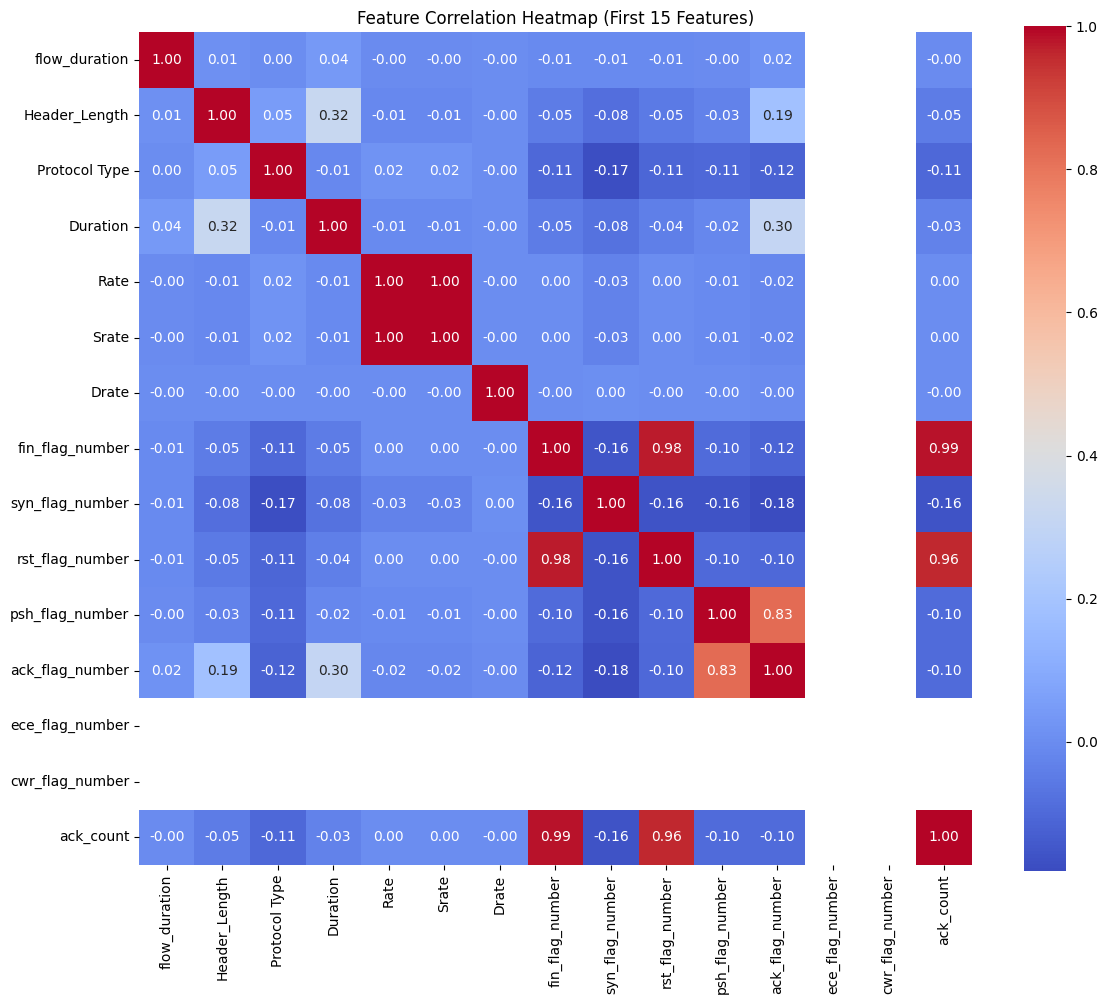

In [62]:
# Correlation heatmap (top 15 features)
plt.figure(figsize=(12, 10))
corr_matrix = df[X.columns[:15]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap (First 15 Features)')
plt.tight_layout()
plt.show()

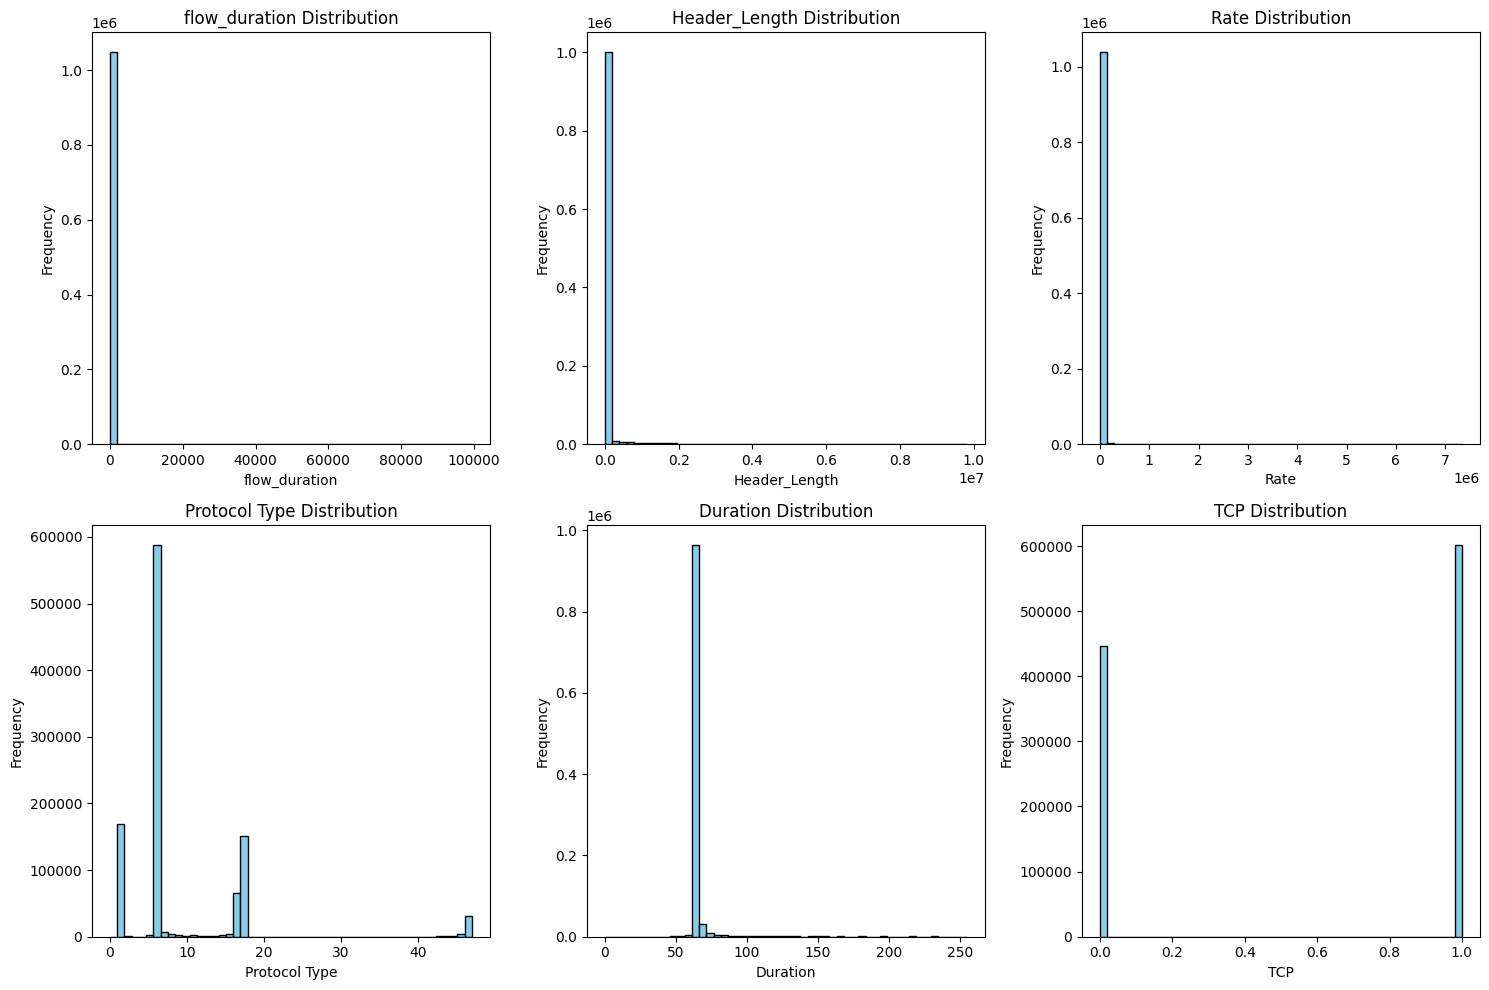

In [63]:
# Distribution of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['flow_duration', 'Header_Length', 'Rate', 'Protocol Type', 'Duration', 'TCP']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=50, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'{feature} Distribution')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [64]:
# Missing values check
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')

Missing values per column:
No missing values


In [65]:
# Sample down to 100k for faster training
from sklearn.utils import resample
X_train_sample, y_train_sample = resample(X_train, y_train, n_samples=100000, random_state=42, stratify=y_train)

print(f'Using {len(X_train_sample)} samples for training')

# Initialize all 6 models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100, random_state=42)
}

# Train all models
results = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_sample, y_train_sample)  # Use sample for training
    y_pred = model.predict(X_test)  # Still test on full test set

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'y_pred': y_pred
    }

    print(f'{name} - Accuracy: {acc:.4f}, F1: {f1:.4f}')

print('\n All 5 models trained')

Using 100000 samples for training

Training Decision Tree...
Decision Tree - Accuracy: 0.9441, F1: 0.9634

Training Random Forest...
Random Forest - Accuracy: 0.9878, F1: 0.9885

Training XGBoost...
XGBoost - Accuracy: 0.9923, F1: 0.9920

Training Logistic Regression...
Logistic Regression - Accuracy: 0.1765, F1: 0.0960

Training MLP...
MLP - Accuracy: 0.7283, F1: 0.6140

 All 5 models trained


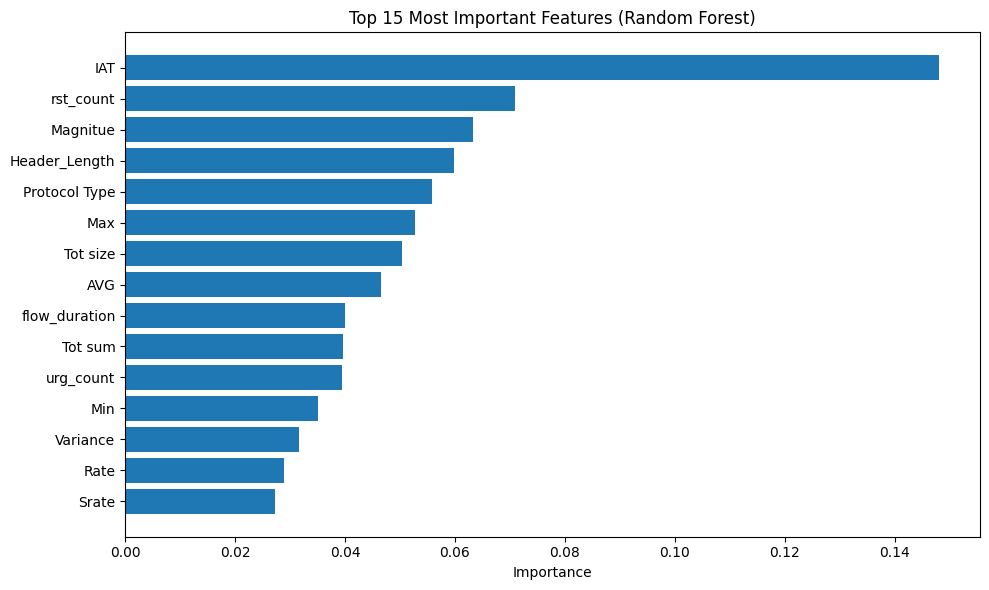

In [66]:
# Feature importance from Random Forest
importances = models['Random Forest'].feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [67]:
# Per-class performance for best model (XGBoost)
from sklearn.metrics import classification_report
print('XGBoost Per-Class Performance:')
print(classification_report(y_test, results['XGBoost']['y_pred'],
                          target_names=le.classes_, digits=4))

XGBoost Per-Class Performance:
              precision    recall  f1-score   support

      Benign     0.8684    0.9205    0.8937      4895
  BruteForce     0.3889    0.1077    0.1687        65
        DDoS     0.9997    0.9996    0.9997    152705
         DoS     0.9989    0.9991    0.9990     36296
       Mirai     0.9997    0.9998    0.9998     11847
       Recon     0.7406    0.6916    0.7153      1589
    Spoofing     0.7955    0.7778    0.7865      2210
   Web-based     0.2692    0.0648    0.1045       108

    accuracy                         0.9923    209715
   macro avg     0.7576    0.6951    0.7084    209715
weighted avg     0.9918    0.9923    0.9920    209715



In [68]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Reshape data for CNN (needs 3D input)
X_train_cnn = X_train_sample.values.reshape(-1, 46, 1)
X_test_cnn = X_test.values.reshape(-1, 46, 1)

# Build 1D-CNN
cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(46, 1)),
    MaxPooling1D(2),
    Conv1D(32, 3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')  # 8 classes
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print('Training 1D-CNN...')
history = cnn_model.fit(X_train_cnn, y_train_sample, epochs=10, batch_size=128, validation_split=0.2, verbose=0)

# Predict
y_pred_cnn = cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = y_pred_cnn.argmax(axis=1)

# Metrics
acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn = f1_score(y_test, y_pred_cnn, average='weighted')

results['1D-CNN'] = {
    'Accuracy': acc_cnn,
    'Precision': precision_score(y_test, y_pred_cnn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_cnn, average='weighted', zero_division=0),
    'F1-Score': f1_cnn,
    'y_pred': y_pred_cnn
}

print(f'1D-CNN - Accuracy: {acc_cnn:.4f}, F1: {f1_cnn:.4f}')
print('\n✅ All 6 models complete!')

Training 1D-CNN...
1D-CNN - Accuracy: 0.7282, F1: 0.6136

✅ All 6 models complete!


              Model  Accuracy  Precision   Recall  F1-Score
            XGBoost  0.992266   0.991850 0.992266  0.991976
      Random Forest  0.987779   0.989873 0.987779  0.988529
      Decision Tree  0.944062   0.989146 0.944062  0.963423
                MLP  0.728298   0.615654 0.728298  0.613971
             1D-CNN  0.728155   0.530212 0.728155  0.613615
Logistic Regression  0.176521   0.250301 0.176521  0.095973


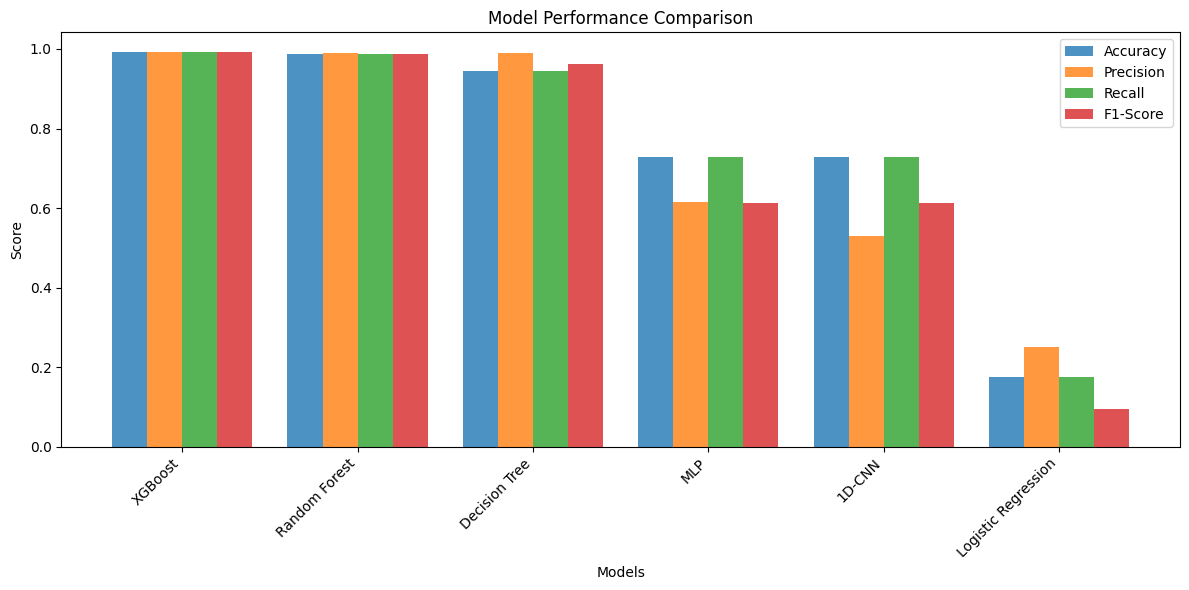

In [69]:
# Results summary
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()]
})

results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
x = range(len(results_df))
width = 0.2

plt.bar([i-width*1.5 for i in x], results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar([i-width*0.5 for i in x], results_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar([i+width*0.5 for i in x], results_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar([i+width*1.5 for i in x], results_df['F1-Score'], width, label='F1-Score', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

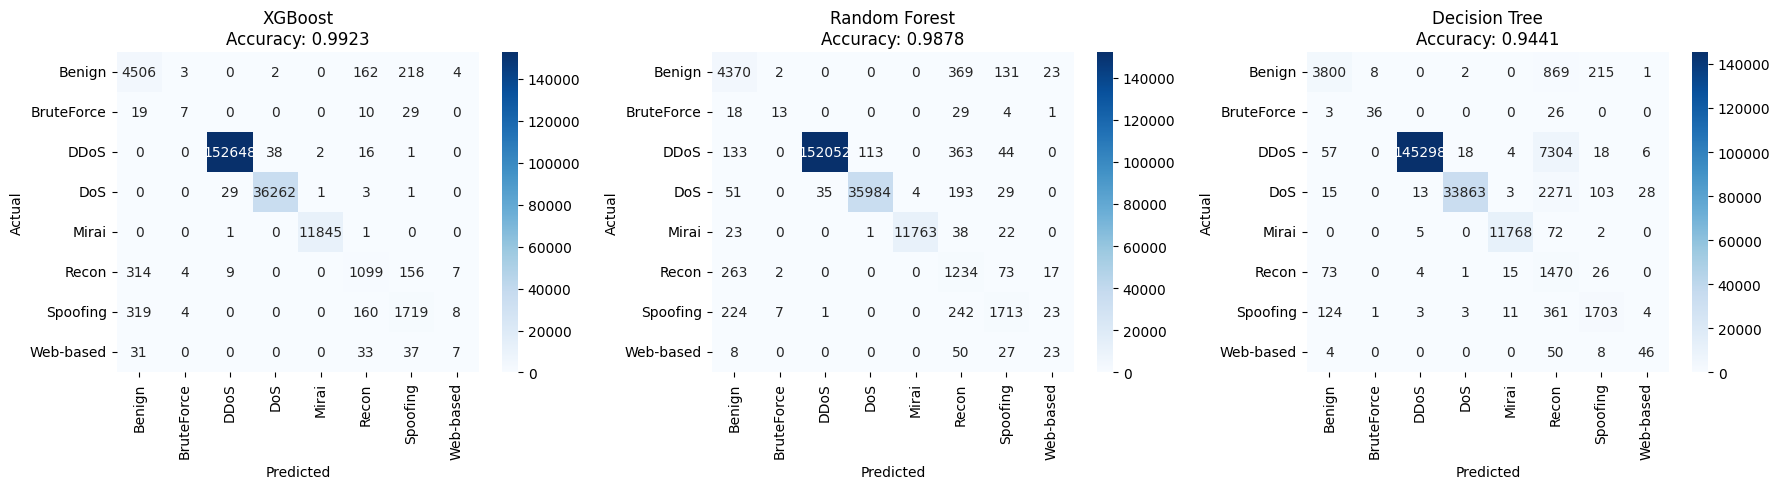

In [70]:
# Plot confusion matrices for top 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_models = ['XGBoost', 'Random Forest', 'Decision Tree']

for idx, model_name in enumerate(top_models):
    cm = confusion_matrix(y_test, results[model_name]['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["Accuracy"]:.4f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()